<a href="https://colab.research.google.com/github/DoctaSTEPHEN/CPE-311--Computational-Thinking-with-Python/blob/main/Hands_on_Activity_5_2_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 5.2 Topic Modeling

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [ ]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets

categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

In [ ]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

In [ ]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [ ]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [ ]:
with open('/content/ap.txt','r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

In [ ]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [ ]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [ ]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20) # We have to look at the topics before hand and then add the labels afterwards


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [ ]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

####Analysis for the Procedure



The procedure shows NLP was used to discover and summarize main themes from a collection of text documents automatically. The data from ap.txt, read fully as string was separated by '---' for each article. Then it was preprocesse using module 're', to remove the HTML tags, converting it into lower cases, and eliminating punctuation and extra spaces. The text data was then converted to numerical data using the CountVectorizer function, considering the use of unigrams, bigrams, and trigrams, and removing common English stop words and common words with high frequencies. LDA analysis was then applied to the data to discover the underlying topics, with the code set to discover 25 topics with probability distributions of the topics for each document. The function 'display_topics' was also used to show the top 20 words in each of the topics, with the option of using human-readable topics.

#### Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

In [ ]:
import pandas as pd
news = pd.read_json('/content/News_Category_Dataset_v3.json', lines=True)
news.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


In [202]:
new_df = news.sample(n=1000, random_state=42)
new_df.head()

,link,headline,category,short_description,authors,date
128310,https://www.huffingtonpost.com/entry/what-if-w...,What If We Were All Family Generation Changers?,IMPACT,"What if, in doing so, we won't just create new...","Matt Murrie, ContributorEdupreneur, Cofounder/...",2014-06-20
139983,https://www.huffingtonpost.comhttp://www.washi...,Firestorm At AOL Over Employee Benefit Cuts,BUSINESS,It should have been a glorious week for AOL ch...,,2014-02-08
42339,https://www.huffingtonpost.com/entry/time-runs...,Dakota Access Protesters Arrested As Deadline ...,POLITICS,A few protesters who refused to leave remained...,"Michael McLaughlin & Josh Morgan, The Huffingt...",2017-02-22
131494,https://www.huffingtonpost.com/entry/one-glimp...,One Glimpse Of These Baby Kit Foxes And You'll...,GREEN,,,2014-05-14
163649,https://www.huffingtonpost.com/entry/mens-swea...,"Mens' Sweat Pheromone, Androstadienone, Influe...",SCIENCE,Scientists didn't know if humans played that g...,Melissa Cronin,2013-06-02


In [203]:
import re
match = re.compile("<[^>]*>").search
docs_news = []
for i,doc in enumerate(new_df.short_description):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs_news.append(' '.join(final).strip().lower().replace("`","").replace("'",""))
docs_news[1]

'it should have been a glorious week for aol chief executive tim armstrong. his company’s quarterly earnings, announced thursday'

In [204]:
print(news.category.unique())
print(news.category.nunique())

['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']
42


In [205]:
from sklearn.decomposition import LatentDirichletAllocation

In [206]:
count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.8)
X_news = count_vectorizer.fit_transform(docs_news)

In [235]:
n_topics = 3
n_iter = 500
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                                learning_method='online',
                                learning_decay=0.8,
                                learning_offset=50)
lda.fit(X_news)

LatentDirichletAllocation(learning_decay=0.8, learning_method='online',
                          learning_offset=50, max_iter=500, n_components=3,
                          random_state=42)

In [236]:
display_topics(lda,count_vectorizer.get_feature_names_out(),20)


Topic  0
people, said, women, make, week, just, want, taking, new, news, know, day, years, really, trump, post, happy, city, republican, change

Topic  1
year, world, new, old, time, just, little, let, year old, president, public, trump, thing, like, things, don, point, believe, said, help

Topic  2
like, time, day, new, people, just, life, love, years, big, youre, feel, family, dont, know, think, right, long, look, got


In [244]:
tn = [
    'Politics & Social Issues',
    'General News & Public Affairs',
    'Personal Life & Relationships']
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Politics & Social Issues '
people, said, women, make, week, just, want, taking, new, news, know, day, years, really, trump, post, happy, city, republican, change

Topic: ' General News & Public Affairs '
year, world, new, old, time, just, little, let, year old, president, public, trump, thing, like, things, don, point, believe, said, help

Topic: ' Personal Life & Relationships '
like, time, day, new, people, just, life, love, years, big, youre, feel, family, dont, know, think, right, long, look, got


In [245]:
doc_topic_dist = lda.transform(X_news)
dominant_topic = np.argmax(doc_topic_dist, axis=1)
new_df['topic'] = dominant_topic
samples_per_topic = new_df.groupby('topic').head(2)

for i in range(len(tn)):
    print(f"\nTopic {i}: {tn[i]}")

    temp = samples_per_topic[samples_per_topic['topic'] == i]

    for j, row in temp.iterrows():
        print(f"\n- {row['headline']}")
        print(f"  {row['short_description']}")


Topic 0: Politics & Social Issues

- Firestorm At AOL Over Employee Benefit Cuts
  It should have been a glorious week for AOL chief executive Tim Armstrong. His company’s quarterly earnings, announced Thursday

- One Glimpse Of These Baby Kit Foxes And You'll Be Hooked
  

Topic 1: General News & Public Affairs

- What If We Were All Family Generation Changers?
  What if, in doing so, we won't just create new opportunities for ourselves, we'll also uncover ways to create new opportunities for our families that may not have otherwise existed?

- Dakota Access Protesters Arrested As Deadline Passes To Depart Camp
  A few protesters who refused to leave remained at the site Thursday.

Topic 2: Personal Life & Relationships

- Summer Sleepover Tips
  Here are five ways to get some beauty sleep while hosting a sleepover for your child.

- Maybe Colleges Should Take A Lesson From Zoos
  By Michael Preston, UCF Forum columnist What would it take to create a more learning-efficient campus? W

In [239]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [240]:
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_news)

kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(X_reduced)

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_reduced)

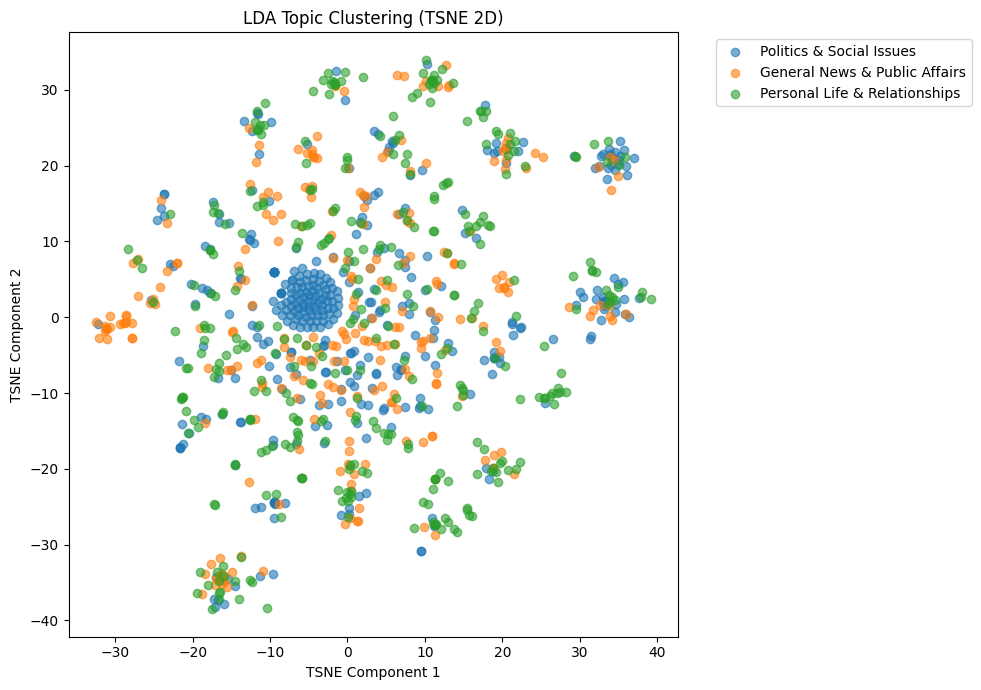

In [246]:
import matplotlib.pyplot as plt

# X_tsne from previous step
plt.figure(figsize=(10,7))

# Loop over each topic to plot separately for legend
for i, topic_name in enumerate(tn):
    idx = dominant_topic == i
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=topic_name, alpha=0.6)

plt.title("LDA Topic Clustering (TSNE 2D)")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # put legend outside
plt.tight_layout()
plt.show()

#### Conclusion

In this activity, I have learned that although LDA can successfully perform the task of extracting topics from the given text data, the topics that are being extracted do not necessarily have to be unique. This can be seen in the clusters that are overlapping in the TSNE plot, wherein this is quite normal in real news data. I have also learned that selecting the appropriate number of topics and tuning the parameters of the model can make the clusters more visible.